# GPT2-small SFT: PLUM-style Next-Watched Retrieval

Canonical SFT stage after SID-v2 and CPT-v2.

Task:
- input: user features + chronological watched history from train split;
- target: the next watched movie Semantic ID;
- target policy: all ratings, no positive-only filtering;
- loss: target-only LM loss;
- eval: constrained trie beam decoding over valid item SIDs.

This notebook is intentionally not executed by Codex. Run it manually.


## 1. Imports and config

Fast-debug profile: both train and validation use 16-event histories. This is meant to verify the full SFT pipeline quickly before switching back to longer histories and heavier validation.

For a later heavier run, increase `TRAIN_HISTORY_WINDOW_CHOICES`, `EVAL_HISTORY_LEN`, `MAX_EPOCHS`, and beam sizes.


In [1]:
from pathlib import Path
from importlib import metadata
from packaging.version import Version
import inspect
import json
import math
import shutil
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from transformers import GPT2LMHeadModel, GPT2TokenizerFast, Trainer, TrainingArguments


In [2]:
try:
    accelerate_version = metadata.version("accelerate")
except metadata.PackageNotFoundError as exc:
    raise ImportError("Install accelerate in this kernel: %pip install -U accelerate") from exc

if Version(accelerate_version) < Version("0.21.0"):
    raise ImportError(f"accelerate>=0.21.0 is required, found {accelerate_version}")

print("accelerate:", accelerate_version)


accelerate: 1.13.0


In [3]:
ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

RUN_NAME = "sft_gpt2_small_sid_v2_next_watch_plum_v1"
BASE_CPT_DIR = ROOT / "data/processed/artifacts/cpt_gpt2_small_sid_v2_qwen4b_plum_curriculum_v2/final"
SID_ARRAY_PATH = ROOT / "runs/qwen4b_rqvae_sid_v2_plum/SIDs_best.npy"
TRAIN_PATH = ROOT / "data/processed/splits/train.parquet"
VAL_PATH = ROOT / "data/processed/splits/val.parquet"
TEST_PATH = ROOT / "data/processed/splits/test.parquet"
USERS_PATH = ROOT / "data/raw/ml-1m/users.dat"

ARTIFACT_DIR = ROOT / "data/processed/artifacts" / RUN_NAME
BEST_MODEL_DIR = ARTIFACT_DIR / "best"
LAST_MODEL_DIR = ARTIFACT_DIR / "last"
METRICS_PATH = ARTIFACT_DIR / "metrics.json"
CONFIG_PATH = ARTIFACT_DIR / "config.json"

SEED = 42
MAX_EPOCHS = 12
MIN_EPOCHS = 4
EARLY_STOPPING_PATIENCE = 3
EARLY_STOPPING_MIN_DELTA = 0.0005
PRIMARY_METRIC = "recall@10"

TARGETS_PER_USER_PER_EPOCH = 4
RECENT_TARGET_FRACTION = 0.50
MIN_HISTORY_LEN = 16
TRAIN_HISTORY_WINDOW_CHOICES = [16]
EVAL_HISTORY_LEN = 16
MAX_SEQ_LENGTH = 256

PER_DEVICE_TRAIN_BATCH_SIZE = 4
PER_DEVICE_EVAL_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 8
LEARNING_RATE = 1e-5
WARMUP_RATIO = 0.04
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0
LOGGING_STEPS = 50

EVAL_BEAM_SIZE = 10
EVAL_NUM_RETURN_SEQUENCES = 10
FULL_EVAL_BEAM_SIZE = 10
FULL_EVAL_NUM_RETURN_SEQUENCES = 10
TOP_K = 10
FILTER_SEEN = True
EVAL_MAX_USERS = 512  # fast monitor sample; set None only for final full validation
FULL_VAL_EVERY = 0  # 0 disables full validation during training; run the final full-val cell after best checkpoint
RUN_TEST_AFTER_TRAINING = False  # keep False until you are happy with validation

USE_DUP_SUFFIX = True
INCLUDE_USER_FEATURES = True
INCLUDE_RATINGS = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BF16 = DEVICE == "cuda" and torch.cuda.is_bf16_supported()
FP16 = DEVICE == "cuda" and not BF16
PRECISION_MODE = "bf16" if BF16 else ("fp16" if FP16 else "fp32")
if DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True

torch.manual_seed(SEED)
np.random.seed(SEED)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print(ROOT)
print("base CPT:", BASE_CPT_DIR)
print("device:", DEVICE, PRECISION_MODE)


C:\Users\User\plum-ml1m-repro
base CPT: C:\Users\User\plum-ml1m-repro\data\processed\artifacts\cpt_gpt2_small_sid_v2_qwen4b_plum_curriculum_v2\final
device: cuda bf16


## 2. Load data

SFT training uses only train interactions. Validation target is `val.parquet`; test target is `test.parquet` and should be used only once after model selection.


In [4]:
assert BASE_CPT_DIR.exists(), BASE_CPT_DIR

train = pd.read_parquet(TRAIN_PATH).sort_values(["user_idx", "timestamp", "pos", "item_idx"]).reset_index(drop=True)
val = pd.read_parquet(VAL_PATH).sort_values(["user_idx", "timestamp", "pos", "item_idx"]).reset_index(drop=True)
test = pd.read_parquet(TEST_PATH).sort_values(["user_idx", "timestamp", "pos", "item_idx"]).reset_index(drop=True)
users = pd.read_csv(
    USERS_PATH,
    sep="::",
    engine="python",
    names=["user_id", "gender", "age", "occupation", "zip"],
    encoding="latin-1",
)
sids = np.load(SID_ARRAY_PATH)

assert sids.shape[0] > int(train["item_idx"].max())
assert sids.shape[1] == 4

print("train:", train.shape, "users:", train.user_id.nunique())
print("val:", val.shape, "users:", val.user_id.nunique())
print("test:", test.shape, "users:", test.user_id.nunique())
print("sids:", sids.shape)
print("train history min/median/max:", train.groupby("user_id").size().agg(["min", "median", "max"]).to_dict())


train: (988129, 8) users: 6040
val: (6040, 8) users: 6040
test: (6040, 8) users: 6040
sids: (3706, 4)
train history min/median/max: {'min': 18.0, 'median': 94.0, 'max': 2312.0}


## 3. Tokenizer, SID tokens, and collision suffixes

There are a few SID collisions. To keep item-level targets, collided items get a small `<dup_i>` suffix. Non-collided items keep the original 4-token SID.


In [5]:
BOS = "<bos>"
EOS = "<eos>"
USER_OPEN = "<user>"
USER_CLOSE = "</user>"
HIST = "<hist>"
EVENT_OPEN = "<e>"
EVENT_CLOSE = "</e>"
TASK_REC = "<task_rec>"
NEXT = "<next>"


def base_sid_tokens(sid):
    return [f"<sid_{level}_{int(code)}>" for level, code in enumerate(sid)]


def rating_token(rating):
    return f"<rat_{int(rating)}>"


def user_tokens(user_row):
    return [f"<gen_{user_row.gender}>", f"<age_{int(user_row.age)}>", f"<occ_{int(user_row.occupation)}>"]

sid_to_items = defaultdict(list)
for item_idx, sid in enumerate(sids):
    sid_to_items[tuple(int(x) for x in sid)].append(int(item_idx))

item_to_dup = {}
dup_tokens = []
for sid_tuple, items in sid_to_items.items():
    if len(items) > 1:
        for dup_idx, item_idx in enumerate(sorted(items)):
            token = f"<dup_{dup_idx}>"
            item_to_dup[item_idx] = token
            dup_tokens.append(token)

def item_sid_tokens(item_idx):
    item_idx = int(item_idx)
    tokens = base_sid_tokens(sids[item_idx])
    if USE_DUP_SUFFIX and item_idx in item_to_dup:
        tokens.append(item_to_dup[item_idx])
    return tokens

all_item_token_tuples = [tuple(item_sid_tokens(i)) for i in range(len(sids))]
print("unique item token sequences:", len(set(all_item_token_tuples)), "/", len(all_item_token_tuples))
print("collision buckets:", sum(len(v) > 1 for v in sid_to_items.values()), "collided items:", len(item_to_dup))


unique item token sequences: 3706 / 3706
collision buckets: 11 collided items: 22


In [6]:
tokenizer = GPT2TokenizerFast.from_pretrained(BASE_CPT_DIR)
extra_tokens = [TASK_REC, NEXT, *sorted(set(dup_tokens))]
added = tokenizer.add_tokens([tok for tok in extra_tokens if tok not in tokenizer.get_vocab()])
print("tokenizer size:", len(tokenizer), "added:", added)


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


tokenizer size: 50646 added: 4


## 4. Build trie and item maps

The trie constrains generation to valid item token sequences only. With duplicate suffixes enabled, every generated path resolves to exactly one item.


In [7]:
def token_ids_for_item(item_idx):
    return tuple(int(x) for x in tokenizer.convert_tokens_to_ids(item_sid_tokens(item_idx)))

item_to_token_ids = {int(i): token_ids_for_item(i) for i in range(len(sids))}
token_ids_to_item = {v: k for k, v in item_to_token_ids.items()}
assert len(token_ids_to_item) == len(item_to_token_ids)

TRIE = {}
EOS_ID = int(tokenizer.eos_token_id)
PAD_ID = int(tokenizer.pad_token_id)

for item_idx, path in item_to_token_ids.items():
    node = TRIE
    for token_id in path:
        node = node.setdefault(int(token_id), {})
    node[EOS_ID] = {}

MAX_TARGET_TOKENS = max(len(path) for path in item_to_token_ids.values()) + 1
print("max target tokens incl eos:", MAX_TARGET_TOKENS)


max target tokens incl eos: 6


## 5. Encode prompts and labels

The prompt is masked with `-100`; loss is computed only on target SID tokens and `<eos>`.


In [8]:
users_by_id = users.set_index("user_id", drop=False)

train_events_by_user = {
    int(user_id): group.sort_values(["timestamp", "pos", "item_idx"], kind="mergesort").to_dict("records")
    for user_id, group in train.groupby("user_id", sort=False)
}

val_target_by_user = {
    int(row.user_id): row._asdict()
    for row in val.sort_values(["user_idx", "timestamp", "pos", "item_idx"]).itertuples(index=False)
}

test_target_by_user = {
    int(row.user_id): row._asdict()
    for row in test.sort_values(["user_idx", "timestamp", "pos", "item_idx"]).itertuples(index=False)
}

train_plus_val_events_by_user = {
    int(user_id): group.sort_values(["timestamp", "pos", "item_idx"], kind="mergesort").to_dict("records")
    for user_id, group in pd.concat([train, val], ignore_index=True).groupby("user_id", sort=False)
}


def event_tokens(event):
    tokens = [EVENT_OPEN]
    tokens.extend(item_sid_tokens(event["item_idx"]))
    if INCLUDE_RATINGS:
        tokens.append(rating_token(event["rating"]))
    tokens.append(EVENT_CLOSE)
    return tokens


def prompt_prefix_tokens(user_id):
    tokens = [BOS, TASK_REC]
    if INCLUDE_USER_FEATURES and user_id in users_by_id.index:
        tokens.append(USER_OPEN)
        tokens.extend(user_tokens(users_by_id.loc[user_id]))
        tokens.append(USER_CLOSE)
    tokens.append(HIST)
    return tokens


def fit_prompt(prefix, history_events, target_tokens):
    event_blocks = [event_tokens(event) for event in history_events]
    while event_blocks:
        prompt_tokens = prefix + [tok for block in event_blocks for tok in block] + [NEXT]
        if len(prompt_tokens) + len(target_tokens) <= MAX_SEQ_LENGTH:
            return prompt_tokens
        event_blocks = event_blocks[1:]
    prompt_tokens = prefix + [NEXT]
    if len(prompt_tokens) + len(target_tokens) > MAX_SEQ_LENGTH:
        raise ValueError("Prompt prefix plus target exceeds MAX_SEQ_LENGTH")
    return prompt_tokens


def encode_sft_example(user_id, history_events, target_event, split):
    target_item = int(target_event["item_idx"])
    target_tokens = item_sid_tokens(target_item) + [EOS]
    prompt_tokens = fit_prompt(prompt_prefix_tokens(user_id), history_events, target_tokens)
    all_tokens = prompt_tokens + target_tokens
    input_ids = tokenizer.convert_tokens_to_ids(all_tokens)
    labels = [-100] * len(prompt_tokens) + input_ids[len(prompt_tokens):]

    if any(token_id == tokenizer.unk_token_id for token_id in input_ids):
        bad = [tok for tok, token_id in zip(all_tokens, input_ids) if token_id == tokenizer.unk_token_id]
        raise ValueError(f"Unknown tokens: {bad[:10]}")

    return {
        "input_ids": input_ids,
        "labels": labels,
        "prompt_length": len(prompt_tokens),
        "user_id": int(user_id),
        "split": split,
        "target_item_idx": target_item,
        "history_item_idx": [int(event["item_idx"]) for event in history_events],
    }


## 6. Dynamic train sampler

Each epoch samples several valid target positions per user. Target positions always have at least `MIN_HISTORY_LEN` previous events.


In [9]:
def sample_target_positions(n_events, rng):
    valid = np.arange(MIN_HISTORY_LEN, n_events, dtype=np.int32)
    if len(valid) == 0:
        return []

    n_recent = int(round(TARGETS_PER_USER_PER_EPOCH * RECENT_TARGET_FRACTION))
    n_random = TARGETS_PER_USER_PER_EPOCH - n_recent

    recent_pool_start = max(MIN_HISTORY_LEN, int(n_events * 0.70))
    recent_pool = np.arange(recent_pool_start, n_events, dtype=np.int32)
    if len(recent_pool) == 0:
        recent_pool = valid

    recent = rng.choice(recent_pool, size=min(n_recent, len(recent_pool)), replace=len(recent_pool) < n_recent)
    random_pos = rng.choice(valid, size=min(n_random, len(valid)), replace=len(valid) < n_random)
    return sorted(set(int(x) for x in np.concatenate([recent, random_pos])))


def build_train_examples_for_epoch(epoch):
    rng = np.random.default_rng(SEED + epoch)
    examples = []
    stats = []

    for user_id, events in train_events_by_user.items():
        positions = sample_target_positions(len(events), rng)
        for target_pos in positions:
            target_event = events[target_pos]
            window = int(rng.choice(TRAIN_HISTORY_WINDOW_CHOICES))
            start = max(0, target_pos - window)
            history_events = events[start:target_pos]
            if len(history_events) < MIN_HISTORY_LEN:
                continue
            ex = encode_sft_example(user_id, history_events, target_event, split="train")
            examples.append(ex)
            stats.append((len(history_events), len(ex["input_ids"])))

    rng.shuffle(examples)
    stats = np.array(stats, dtype=np.int32) if stats else np.zeros((0, 2), dtype=np.int32)
    epoch_stats = {
        "epoch": int(epoch),
        "examples": int(len(examples)),
        "history_p50": int(np.percentile(stats[:, 0], 50)) if len(stats) else 0,
        "history_p95": int(np.percentile(stats[:, 0], 95)) if len(stats) else 0,
        "length_p50": int(np.percentile(stats[:, 1], 50)) if len(stats) else 0,
        "length_p95": int(np.percentile(stats[:, 1], 95)) if len(stats) else 0,
        "length_max": int(stats[:, 1].max()) if len(stats) else 0,
    }
    return examples, epoch_stats

train_preview, train_preview_stats = build_train_examples_for_epoch(0)
train_preview_stats


{'epoch': 0,
 'examples': 23121,
 'history_p50': 16,
 'history_p95': 16,
 'length_p50': 126,
 'length_p95': 126,
 'length_max': 130}

## 7. Eval examples

Validation uses train history as context and val item as target. Test uses train+val as context and test item as target.


In [10]:
def build_eval_examples(split="val", max_users=None, seed=SEED):
    if split == "val":
        context_by_user = train_events_by_user
        target_by_user = val_target_by_user
    elif split == "test":
        context_by_user = train_plus_val_events_by_user
        target_by_user = test_target_by_user
    else:
        raise ValueError("split must be 'val' or 'test'")

    user_ids = sorted(target_by_user.keys())
    if max_users is not None:
        rng = np.random.default_rng(seed)
        user_ids = sorted(rng.choice(user_ids, size=min(max_users, len(user_ids)), replace=False).tolist())

    examples = []
    for user_id in user_ids:
        history = context_by_user.get(int(user_id), [])[-EVAL_HISTORY_LEN:]
        if len(history) < MIN_HISTORY_LEN:
            continue
        examples.append(encode_sft_example(user_id, history, target_by_user[user_id], split=split))
    return examples

val_examples = build_eval_examples("val", max_users=EVAL_MAX_USERS)
full_val_examples = build_eval_examples("val", max_users=None)
print("val eval examples:", len(val_examples), "full val:", len(full_val_examples))


val eval examples: 512 full val: 6040


## 8. Dataset and collator

In [11]:
class SFTListDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        return {"input_ids": ex["input_ids"], "labels": ex["labels"]}


class TargetOnlyCollator:
    def __init__(self, tokenizer, pad_to_multiple_of=8):
        self.tokenizer = tokenizer
        self.pad_to_multiple_of = pad_to_multiple_of

    def __call__(self, features):
        max_len = max(len(f["input_ids"]) for f in features)
        if self.pad_to_multiple_of:
            max_len = int(math.ceil(max_len / self.pad_to_multiple_of) * self.pad_to_multiple_of)

        input_ids, attention_mask, labels = [], [], []
        for f in features:
            n = len(f["input_ids"])
            pad = max_len - n
            input_ids.append(f["input_ids"] + [PAD_ID] * pad)
            attention_mask.append([1] * n + [0] * pad)
            labels.append(f["labels"] + [-100] * pad)

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
        }

collator = TargetOnlyCollator(tokenizer)


## 9. Constrained trie beam eval

Per-epoch eval is intentionally light: validation sample + smaller beam. Full validation over all 6040 users is expensive and is disabled during training by default with `FULL_VAL_EVERY = 0`.

Run full validation only after the best checkpoint is selected, using the final evaluation cell. If you enable full validation during training, expect it to be slow because it performs autoregressive trie-beam generation separately for every validation user.

Before generation, the notebook switches the model back to inference mode with KV-cache enabled. This matters because training uses gradient checkpointing and `use_cache=False`, which makes autoregressive generation much slower.


In [12]:
def set_generation_mode(model):
    model.eval()
    model.config.use_cache = True
    if hasattr(model, "gradient_checkpointing_disable"):
        model.gradient_checkpointing_disable()
    torch.cuda.empty_cache() if DEVICE == "cuda" else None


def set_training_mode(model):
    model.train()
    model.config.use_cache = False
    if hasattr(model, "gradient_checkpointing_enable"):
        model.gradient_checkpointing_enable()


def trie_allowed_tokens(prompt_length):
    def allowed(_batch_id, input_ids):
        node = TRIE
        generated = input_ids[prompt_length:].tolist()
        for token_id in generated:
            token_id = int(token_id)
            if token_id not in node:
                return [EOS_ID]
            node = node[token_id]
        return sorted(node.keys()) if node else [EOS_ID]
    return allowed


def decode_generated_item(sequence_ids, prompt_length):
    new_ids = []
    for token_id in sequence_ids[prompt_length:].tolist():
        token_id = int(token_id)
        if token_id in {EOS_ID, PAD_ID}:
            break
        new_ids.append(token_id)
    return token_ids_to_item.get(tuple(new_ids))


def generate_candidates(
    model,
    example,
    beam_size=EVAL_BEAM_SIZE,
    top_k=TOP_K,
    num_return_sequences=EVAL_NUM_RETURN_SEQUENCES,
    filter_seen=FILTER_SEEN,
):
    prompt_ids = example["input_ids"][:example["prompt_length"]]
    input_ids = torch.tensor([prompt_ids], dtype=torch.long, device=DEVICE)
    attention_mask = torch.ones_like(input_ids)
    seen = set(example.get("history_item_idx", [])) if filter_seen else set()
    num_return_sequences = min(int(num_return_sequences), int(beam_size))

    with torch.inference_mode():
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=MAX_TARGET_TOKENS,
            num_beams=beam_size,
            num_return_sequences=num_return_sequences,
            do_sample=False,
            early_stopping=True,
            pad_token_id=PAD_ID,
            eos_token_id=EOS_ID,
            prefix_allowed_tokens_fn=trie_allowed_tokens(len(prompt_ids)),
            use_cache=True,
        )

    candidates = []
    raw_items = []
    invalid = 0
    seen_generated = 0
    used = set()

    for seq in outputs:
        item = decode_generated_item(seq, len(prompt_ids))
        if item is None:
            invalid += 1
            continue
        raw_items.append(int(item))
        if item in seen:
            seen_generated += 1
            continue
        if item in used:
            continue
        candidates.append(int(item))
        used.add(int(item))
        if len(candidates) >= top_k:
            break

    return {
        "candidates": candidates,
        "raw_items": raw_items,
        "invalid_sid_count": invalid,
        "seen_generated_count": seen_generated,
        "generated_count": int(len(outputs)),
    }


def recall_at_k(candidates, target, k):
    return float(int(int(target) in candidates[:k]))


def ndcg_at_k(candidates, target, k):
    target = int(target)
    for rank, item in enumerate(candidates[:k], start=1):
        if int(item) == target:
            return 1.0 / math.log2(rank + 1)
    return 0.0


def mrr_at_k(candidates, target, k):
    target = int(target)
    for rank, item in enumerate(candidates[:k], start=1):
        if int(item) == target:
            return 1.0 / rank
    return 0.0


def evaluate_model(
    model,
    examples,
    name="val",
    beam_size=EVAL_BEAM_SIZE,
    top_k=TOP_K,
    num_return_sequences=EVAL_NUM_RETURN_SEQUENCES,
):
    set_generation_mode(model)
    records = []
    iterator = tqdm(examples, desc=f"eval {name}", leave=False)
    for ex in iterator:
        gen = generate_candidates(
            model,
            ex,
            beam_size=beam_size,
            top_k=top_k,
            num_return_sequences=num_return_sequences,
        )
        records.append({
            "user_id": ex["user_id"],
            "target_item_idx": int(ex["target_item_idx"]),
            **gen,
        })

    metrics = {"split": name, "n": len(records)}
    recommended = set()
    invalid = 0
    generated = 0
    seen_generated = 0
    candidate_counts = []

    for rec in records:
        target = int(rec["target_item_idx"])
        candidates = rec["candidates"]
        recommended.update(candidates)
        candidate_counts.append(len(candidates))
        invalid += int(rec["invalid_sid_count"])
        generated += int(rec["generated_count"])
        seen_generated += int(rec["seen_generated_count"])
        for k in [1, 5, 10]:
            metrics[f"recall@{k}"] = metrics.get(f"recall@{k}", 0.0) + recall_at_k(candidates, target, k)
            metrics[f"ndcg@{k}"] = metrics.get(f"ndcg@{k}", 0.0) + ndcg_at_k(candidates, target, k)
            metrics[f"mrr@{k}"] = metrics.get(f"mrr@{k}", 0.0) + mrr_at_k(candidates, target, k)

    n = max(len(records), 1)
    for key in list(metrics):
        if "@" in key:
            metrics[key] /= n

    metrics["coverage@10"] = int(len(recommended))
    metrics["avg_candidates"] = float(np.mean(candidate_counts)) if candidate_counts else 0.0
    metrics["invalid_sid_rate"] = invalid / max(generated, 1)
    metrics["seen_generated_rate"] = seen_generated / max(generated, 1)
    return metrics, records


## 10. Load model

In [13]:
model = GPT2LMHeadModel.from_pretrained(
    BASE_CPT_DIR,
    torch_dtype=torch.bfloat16 if BF16 else (torch.float16 if FP16 else torch.float32),
)
model.resize_token_embeddings(len(tokenizer))
model.config.bos_token_id = tokenizer.bos_token_id
model.config.eos_token_id = tokenizer.eos_token_id
model.config.pad_token_id = tokenizer.pad_token_id
model.config.use_cache = False
model.to(DEVICE)

if hasattr(model, "gradient_checkpointing_enable"):
    model.gradient_checkpointing_enable()

print("parameters:", sum(p.numel() for p in model.parameters()))


parameters: 124738560


## 11. Train with RecSys early stopping

The model is saved by validation `recall@10`. Early stopping starts only after `MIN_EPOCHS`.


In [14]:
def make_training_args(epoch):
    args_kwargs = {
        "output_dir": str(ARTIFACT_DIR / "trainer_tmp" / f"epoch_{epoch:03d}"),
        "overwrite_output_dir": True,
        "num_train_epochs": 1.0,
        "learning_rate": LEARNING_RATE,
        "warmup_ratio": WARMUP_RATIO,
        "weight_decay": WEIGHT_DECAY,
        "per_device_train_batch_size": PER_DEVICE_TRAIN_BATCH_SIZE,
        "per_device_eval_batch_size": PER_DEVICE_EVAL_BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "logging_steps": LOGGING_STEPS,
        "save_strategy": "no",
        "fp16": FP16,
        "bf16": BF16,
        "report_to": "none",
        "remove_unused_columns": False,
        "dataloader_num_workers": 0,
        "dataloader_pin_memory": DEVICE == "cuda",
        "max_grad_norm": MAX_GRAD_NORM,
    }
    params = inspect.signature(TrainingArguments).parameters
    return TrainingArguments(**{k: v for k, v in args_kwargs.items() if k in params})


def save_model_bundle(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(path)
    tokenizer.save_pretrained(path)

config = {
    "run_name": RUN_NAME,
    "base_cpt_dir": str(BASE_CPT_DIR),
    "sid_array_path": str(SID_ARRAY_PATH),
    "task": "next_watched_item_all_ratings",
    "target_only_loss": True,
    "use_dup_suffix": USE_DUP_SUFFIX,
    "max_epochs": MAX_EPOCHS,
    "min_epochs": MIN_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "primary_metric": PRIMARY_METRIC,
    "min_history_len": MIN_HISTORY_LEN,
    "train_history_window_choices": TRAIN_HISTORY_WINDOW_CHOICES,
    "eval_history_len": EVAL_HISTORY_LEN,
    "max_seq_length": MAX_SEQ_LENGTH,
    "targets_per_user_per_epoch": TARGETS_PER_USER_PER_EPOCH,
    "eval_beam_size": EVAL_BEAM_SIZE,
    "full_eval_beam_size": FULL_EVAL_BEAM_SIZE,
    "top_k": TOP_K,
    "filter_seen": FILTER_SEEN,
    "eval_max_users": EVAL_MAX_USERS,
}
with CONFIG_PATH.open("w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

metrics_history = []
best_metric = -1.0
best_epoch = None
bad_epochs = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_examples, epoch_data_stats = build_train_examples_for_epoch(epoch)
    train_ds = SFTListDataset(train_examples)

    args = make_training_args(epoch)
    trainer_kwargs = {
        "model": model,
        "args": args,
        "train_dataset": train_ds,
        "data_collator": collator,
    }
    trainer_params = inspect.signature(Trainer).parameters
    if "processing_class" in trainer_params:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer

    set_training_mode(model)
    trainer = Trainer(**trainer_kwargs)
    train_output = trainer.train()
    del trainer
    torch.cuda.empty_cache() if DEVICE == "cuda" else None

    eval_name = "val_full" if EVAL_MAX_USERS is None else f"val_sample_{len(val_examples)}"
    eval_metrics, _ = evaluate_model(
        model,
        val_examples,
        name=eval_name,
        beam_size=EVAL_BEAM_SIZE,
        top_k=TOP_K,
        num_return_sequences=EVAL_NUM_RETURN_SEQUENCES,
    )

    full_metrics = None
    if FULL_VAL_EVERY and epoch % FULL_VAL_EVERY == 0 and len(full_val_examples) != len(val_examples):
        full_metrics, _ = evaluate_model(
            model,
            full_val_examples,
            name="val_full",
            beam_size=FULL_EVAL_BEAM_SIZE,
            top_k=TOP_K,
            num_return_sequences=FULL_EVAL_NUM_RETURN_SEQUENCES,
        )

    current = float(eval_metrics[PRIMARY_METRIC])
    improved = current > best_metric + EARLY_STOPPING_MIN_DELTA
    if improved:
        best_metric = current
        best_epoch = epoch
        bad_epochs = 0
        save_model_bundle(BEST_MODEL_DIR)
    else:
        bad_epochs += 1

    row = {
        "epoch": epoch,
        "train_loss": float(train_output.metrics.get("train_loss", np.nan)),
        "train_runtime": float(train_output.metrics.get("train_runtime", np.nan)),
        "best_epoch": best_epoch,
        "best_metric": best_metric,
        "bad_epochs": bad_epochs,
        "improved": improved,
        **epoch_data_stats,
        **{f"eval_{k}": v for k, v in eval_metrics.items() if k != "split"},
    }
    if full_metrics is not None:
        row.update({f"full_{k}": v for k, v in full_metrics.items() if k != "split"})

    metrics_history.append(row)
    with METRICS_PATH.open("w", encoding="utf-8") as f:
        json.dump(metrics_history, f, ensure_ascii=False, indent=2)

    print(json.dumps(row, indent=2))

    if epoch >= MIN_EPOCHS and bad_epochs >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch}: best_epoch={best_epoch}, best_{PRIMARY_METRIC}={best_metric:.6f}")
        break

set_generation_mode(model)
save_model_bundle(LAST_MODEL_DIR)
summary = {
    "best_epoch": best_epoch,
    "best_metric": best_metric,
    "best_model_dir": str(BEST_MODEL_DIR),
    "last_model_dir": str(LAST_MODEL_DIR),
    "epochs_completed": len(metrics_history),
}
with (ARTIFACT_DIR / "summary.json").open("w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
summary


Step,Training Loss
50,4.593400
100,3.473100
150,2.957600
200,2.467700
250,2.022200
300,1.797800
350,1.672900
400,1.628500
450,1.595800
500,1.585500


eval val_sample_512:   0%|          | 0/512 [00:00<?, ?it/s]

{
  "epoch": 1,
  "train_loss": 2.126767405855176,
  "train_runtime": 284.0232,
  "best_epoch": 1,
  "best_metric": 0.138671875,
  "bad_epochs": 0,
  "improved": true,
  "examples": 23095,
  "history_p50": 16,
  "history_p95": 16,
  "length_p50": 126,
  "length_p95": 126,
  "length_max": 130,
  "eval_n": 512,
  "eval_recall@1": 0.03125,
  "eval_ndcg@1": 0.03125,
  "eval_mrr@1": 0.03125,
  "eval_recall@5": 0.091796875,
  "eval_ndcg@5": 0.06005161049109643,
  "eval_mrr@5": 0.049772135416666655,
  "eval_recall@10": 0.138671875,
  "eval_ndcg@10": 0.07553910301777865,
  "eval_mrr@10": 0.05634998139880952,
  "eval_coverage@10": 712,
  "eval_avg_candidates": 8.5859375,
  "eval_invalid_sid_rate": 0.0,
  "eval_seen_generated_rate": 0.14140625
}


Step,Training Loss
50,1.520000
100,1.475500
150,1.435200
200,1.416500
250,1.416600
300,1.406300
350,1.377800
400,1.373400
450,1.412200
500,1.392100


eval val_sample_512:   0%|          | 0/512 [00:00<?, ?it/s]

...

{
  "epoch": 6,
  "train_loss": 1.3314850429418674,
  "train_runtime": 278.0915,
  "best_epoch": 4,
  "best_metric": 0.1640625,
  "bad_epochs": 2,
  "improved": false,
  "examples": 23132,
  "history_p50": 16,
  "history_p95": 16,
  "length_p50": 126,
  "length_p95": 126,
  "length_max": 130,
  "eval_n": 512,
  "eval_recall@1": 0.04296875,
  "eval_ndcg@1": 0.04296875,
  "eval_mrr@1": 0.04296875,
  "eval_recall@5": 0.111328125,
  "eval_ndcg@5": 0.0758502683114675,
  "eval_mrr@5": 0.06442057291666665,
  "eval_recall@10": 0.162109375,
  "eval_ndcg@10": 0.09273915223016221,
  "eval_mrr@10": 0.07165566096230161,
  "eval_coverage@10": 740,
  "eval_avg_candidates": 8.48046875,
  "eval_invalid_sid_rate": 0.0,
  "eval_seen_generated_rate": 0.151953125
}


Step,Training Loss
50,1.332100
100,1.322300
150,1.300300
200,1.334200
250,1.309200
300,1.331500
350,1.343800
400,1.330500
450,1.317200
500,1.298300


eval val_sample_512:   0%|          | 0/512 [00:00<?, ?it/s]

{
  "epoch": 7,
  "train_loss": 1.322482541121172,
  "train_runtime": 275.965,
  "best_epoch": 4,
  "best_metric": 0.1640625,
  "bad_epochs": 3,
  "improved": false,
  "examples": 23178,
  "history_p50": 16,
  "history_p95": 16,
  "length_p50": 126,
  "length_p95": 126,
  "length_max": 130,
  "eval_n": 512,
  "eval_recall@1": 0.04296875,
  "eval_ndcg@1": 0.04296875,
  "eval_mrr@1": 0.04296875,
  "eval_recall@5": 0.107421875,
  "eval_ndcg@5": 0.07403359827410755,
  "eval_mrr@5": 0.06324869791666665,
  "eval_recall@10": 0.1640625,
  "eval_ndcg@10": 0.0928853833592614,
  "eval_mrr@10": 0.07133246527777777,
  "eval_coverage@10": 742,
  "eval_avg_candidates": 8.482421875,
  "eval_invalid_sid_rate": 0.0,
  "eval_seen_generated_rate": 0.1517578125
}
Early stopping at epoch 7: best_epoch=4, best_recall@10=0.164062


{'best_epoch': 4,
 'best_metric': 0.1640625,
 'best_model_dir': 'C:\\Users\\User\\plum-ml1m-repro\\data\\processed\\artifacts\\sft_gpt2_small_sid_v2_next_watch_plum_v1\\best',
 'last_model_dir': 'C:\\Users\\User\\plum-ml1m-repro\\data\\processed\\artifacts\\sft_gpt2_small_sid_v2_next_watch_plum_v1\\last',
 'epochs_completed': 7}

## 12. Training curves

In [15]:
metrics_df = pd.DataFrame(metrics_history if "metrics_history" in globals() else json.loads(METRICS_PATH.read_text(encoding="utf-8")))
metrics_df.tail()


,epoch,train_loss,train_runtime,best_epoch,best_metric,bad_epochs,improved,examples,history_p50,history_p95,...,eval_recall@5,eval_ndcg@5,eval_mrr@5,eval_recall@10,eval_ndcg@10,eval_mrr@10,eval_coverage@10,eval_avg_candidates,eval_invalid_sid_rate,eval_seen_generated_rate
2,3,1.366108,271.3834,2,0.156250,1,False,23117,16,16,...,0.101562,0.071135,0.061263,0.154297,0.088457,0.068563,717,8.486328,0.0,0.151367
3,4,1.349132,283.8356,4,0.164062,0,True,23129,16,16,...,0.105469,0.072827,0.062240,0.164062,0.092419,0.070695,719,8.486328,0.0,0.151367
4,5,1.336160,287.2282,4,0.164062,1,False,23124,16,16,...,0.111328,0.075629,0.064160,0.162109,0.092314,0.071191,730,8.494141,0.0,0.150586
5,6,1.331485,278.0915,4,0.164062,2,False,23132,16,16,...,0.111328,0.075850,0.064421,0.162109,0.092739,0.071656,740,8.480469,0.0,0.151953
6,7,1.322483,275.9650,4,0.164062,3,False,23178,16,16,...,0.107422,0.074034,0.063249,0.164062,0.092885,0.071332,742,8.482422,0.0,0.151758


WindowsPath('C:/Users/User/plum-ml1m-repro/data/processed/artifacts/sft_gpt2_small_sid_v2_next_watch_plum_v1/sft_training_curves.png')

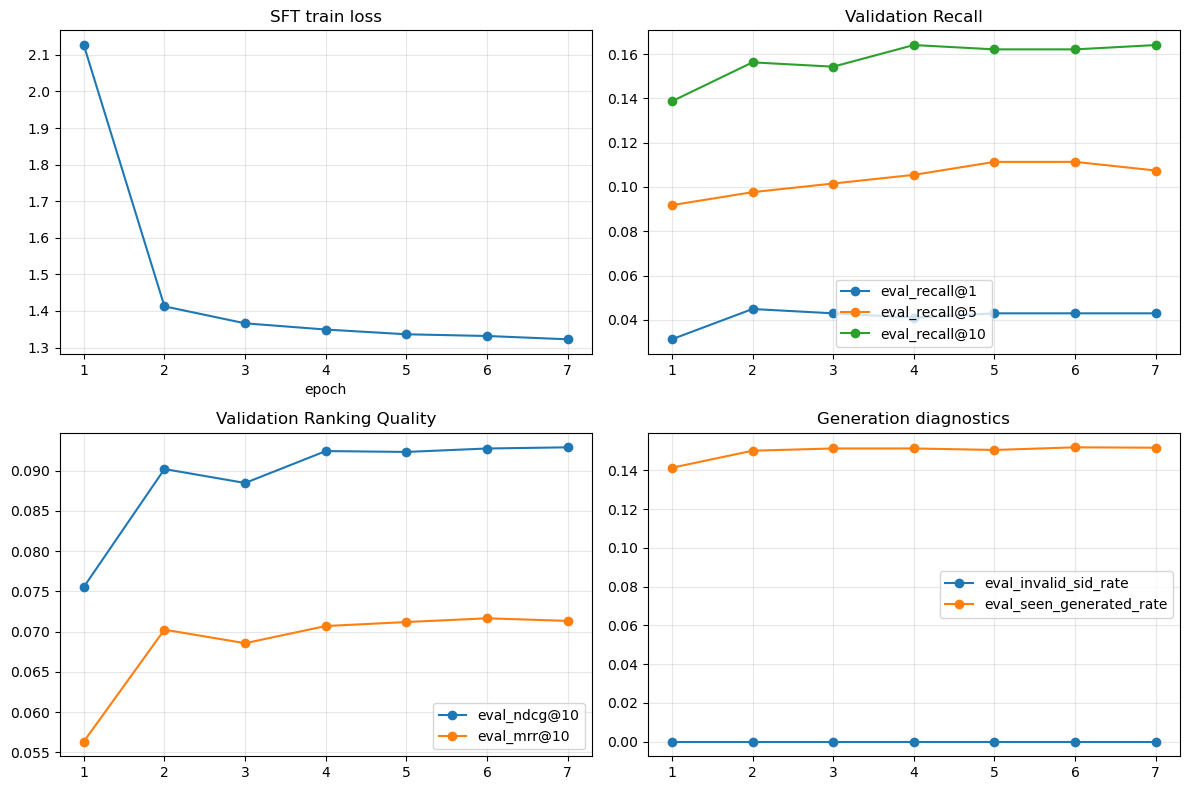

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

axes[0].plot(metrics_df["epoch"], metrics_df["train_loss"], marker="o")
axes[0].set_title("SFT train loss")
axes[0].set_xlabel("epoch")

for metric in ["eval_recall@1", "eval_recall@5", "eval_recall@10"]:
    if metric in metrics_df:
        axes[1].plot(metrics_df["epoch"], metrics_df[metric], marker="o", label=metric)
axes[1].set_title("Validation Recall")
axes[1].legend()

for metric in ["eval_ndcg@10", "eval_mrr@10"]:
    if metric in metrics_df:
        axes[2].plot(metrics_df["epoch"], metrics_df[metric], marker="o", label=metric)
axes[2].set_title("Validation Ranking Quality")
axes[2].legend()

for metric in ["eval_invalid_sid_rate", "eval_seen_generated_rate"]:
    if metric in metrics_df:
        axes[3].plot(metrics_df["epoch"], metrics_df[metric], marker="o", label=metric)
axes[3].set_title("Generation diagnostics")
axes[3].legend()

for ax in axes:
    ax.grid(alpha=0.3)

fig.tight_layout()
plot_path = ARTIFACT_DIR / "sft_training_curves.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plot_path


## 13. Full validation and optional test on best checkpoint

Run test only after model selection is done. Validation can be rerun freely.


In [17]:
best_tokenizer = GPT2TokenizerFast.from_pretrained(BEST_MODEL_DIR)
best_model = GPT2LMHeadModel.from_pretrained(
    BEST_MODEL_DIR,
    torch_dtype=torch.bfloat16 if BF16 else (torch.float16 if FP16 else torch.float32),
).to(DEVICE)
best_model.eval()

# Keep global model/tokenizer references aligned for evaluation helpers.
tokenizer = best_tokenizer
model = best_model

full_val_metrics, full_val_records = evaluate_model(
    model,
    full_val_examples,
    name="val_full_best",
    beam_size=FULL_EVAL_BEAM_SIZE,
    top_k=TOP_K,
    num_return_sequences=FULL_EVAL_NUM_RETURN_SEQUENCES,
)
with (ARTIFACT_DIR / "full_val_metrics.json").open("w", encoding="utf-8") as f:
    json.dump(full_val_metrics, f, ensure_ascii=False, indent=2)
full_val_metrics


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


eval val_full_best:   0%|          | 0/6040 [00:00<?, ?it/s]

{'split': 'val_full_best',
 'n': 6040,
 'recall@1': 0.03360927152317881,
 'ndcg@1': 0.03360927152317881,
 'mrr@1': 0.03360927152317881,
 'recall@5': 0.10745033112582782,
 'ndcg@5': 0.07080418536481017,
 'mrr@5': 0.05881898454746118,
 'recall@10': 0.14619205298013246,
 'ndcg@10': 0.08360090472477359,
 'mrr@10': 0.0642533900977608,
 'coverage@10': 1185,
 'avg_candidates': 8.487251655629139,
 'invalid_sid_rate': 0.0,
 'seen_generated_rate': 0.1512748344370861}

In [18]:
if RUN_TEST_AFTER_TRAINING:
    test_examples = build_eval_examples("test", max_users=None)
    test_metrics, test_records = evaluate_model(
        model,
        test_examples,
        name="test_best",
        beam_size=FULL_EVAL_BEAM_SIZE,
        top_k=TOP_K,
        num_return_sequences=FULL_EVAL_NUM_RETURN_SEQUENCES,
    )
    with (ARTIFACT_DIR / "test_metrics.json").open("w", encoding="utf-8") as f:
        json.dump(test_metrics, f, ensure_ascii=False, indent=2)
    test_metrics
else:
    print("RUN_TEST_AFTER_TRAINING=False; test split is untouched.")


RUN_TEST_AFTER_TRAINING=False; test split is untouched.


## 14. Qualitative generation check

In [19]:
sample = full_val_examples[0]
prompt_ids = sample["input_ids"][:sample["prompt_length"]]
prompt_text = tokenizer.decode(prompt_ids, skip_special_tokens=False)
gen = generate_candidates(model, sample, beam_size=EVAL_BEAM_SIZE, top_k=TOP_K, num_return_sequences=EVAL_NUM_RETURN_SEQUENCES)
print(prompt_text[-1500:])
print("target:", sample["target_item_idx"], item_sid_tokens(sample["target_item_idx"]))
print("candidates:", gen["candidates"])
print("candidate tokens:", [item_sid_tokens(i) for i in gen["candidates"][:5]])


<bos><task_rec><user><gen_F><age_1><occ_10></user><hist><e><sid_0_32><sid_1_89><sid_2_103><sid_3_44><rat_3></e><e><sid_0_469><sid_1_203><sid_2_35><sid_3_53><rat_5></e><e><sid_0_77><sid_1_77><sid_2_84><sid_3_27><rat_3></e><e><sid_0_469><sid_1_203><sid_2_84><sid_3_48><rat_4></e><e><sid_0_470><sid_1_169><sid_2_34><sid_3_37><rat_4></e><e><sid_0_78><sid_1_177><sid_2_86><sid_3_27><rat_4></e><e><sid_0_438><sid_1_122><sid_2_13><sid_3_24><rat_5></e><e><sid_0_469><sid_1_134><sid_2_77><sid_3_48><rat_5></e><e><sid_0_469><sid_1_139><sid_2_93><sid_3_23><rat_3></e><e><sid_0_32><sid_1_134><sid_2_109><sid_3_52><rat_3></e><e><sid_0_469><sid_1_77><sid_2_84><sid_3_33><rat_4></e><e><sid_0_32><sid_1_134><sid_2_20><sid_3_18><rat_5></e><e><sid_0_32><sid_1_216><sid_2_30><sid_3_26><rat_5></e><e><sid_0_469><sid_1_7><sid_2_49><sid_3_26><rat_4></e><e><sid_0_469><sid_1_138><sid_2_89><sid_3_48><rat_4></e><e><sid_0_469><sid_1_102><sid_2_41><sid_3_49><rat_4></e><next>
target: 1727 ['<sid_0_469>', '<sid_1_24>', '<sid_2